# Model Development and Final Evaluation

## Executive summary

Three fixed candidates are compared on a future validation snapshot. Logistic
Regression is selected because its PR-AUC is best and paired uncertainty does
not demonstrate a meaningful advantage for the more complex alternatives.
Sigmoid calibration then converts its scores into usable probability
estimates. The frozen workflow is evaluated once on the reserved 2025 test.

All records and outcomes are synthetic. Metrics describe predictive
performance in this simulation, not guaranteed accuracy for real employees.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "config" / "portfolio_notebooks.yaml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook inside the project repository.")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Temporal model comparison

Models train on the 2023 snapshot and are compared on the 2024 snapshot.
PR-AUC is primary because attrition is the minority class.

In [2]:
models = pd.read_csv(PROCESSED / "model_comparison_v2.csv")
model_table = models[
    [
        "model",
        "pr_auc",
        "pr_auc_lower_95",
        "pr_auc_upper_95",
        "roc_auc",
        "brier_score",
        "top_decile_lift",
        "grouped_cv_pr_auc_mean",
        "selected_model",
    ]
].copy()
display(model_table.round(3))

,model,pr_auc,pr_auc_lower_95,pr_auc_upper_95,roc_auc,brier_score,top_decile_lift,grouped_cv_pr_auc_mean,selected_model
0,Logistic Regression,0.164,0.148,0.186,0.621,0.240,1.857,0.167,True
1,Gradient Boosting,0.161,0.148,0.180,0.629,0.207,1.755,0.166,False
2,Random Forest,0.152,0.140,0.167,0.622,0.172,1.721,0.157,False


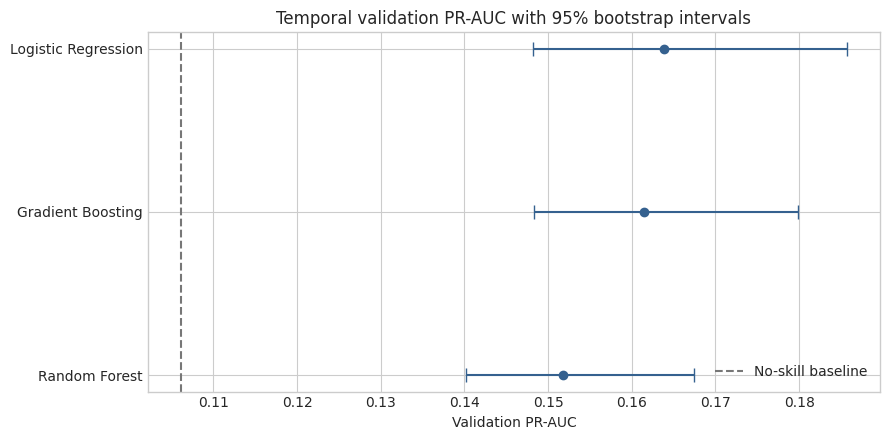

In [3]:
plot_models = models.sort_values("pr_auc")
lower = plot_models["pr_auc"] - plot_models["pr_auc_lower_95"]
upper = plot_models["pr_auc_upper_95"] - plot_models["pr_auc"]

plt.figure(figsize=(9, 4.5))
plt.errorbar(
    plot_models["pr_auc"],
    plot_models["model"],
    xerr=[lower, upper],
    fmt="o",
    capsize=5,
    color="#35618f",
)
plt.axvline(
    models["positive_rate"].iloc[0],
    color="#777777",
    linestyle="--",
    label="No-skill baseline",
)
plt.xlabel("Validation PR-AUC")
plt.title("Temporal validation PR-AUC with 95% bootstrap intervals")
plt.legend()
plt.tight_layout()
plt.show()

The Logistic Regression and Gradient Boosting difference is inconclusive.
The committed selection rule therefore prefers the simpler, more
interpretable model.

## Probability calibration

Uncalibrated Logistic Regression scores rank employees moderately well but
substantially overstate absolute probabilities. Sigmoid and isotonic mappings
learn only from out-of-fold training predictions.

In [4]:
calibration = pd.read_csv(
    PROCESSED / "retention_calibration_metrics.csv"
)
display(
    calibration[
        [
            "method",
            "brier_score",
            "log_loss",
            "expected_calibration_error",
            "mean_predicted_probability",
            "observed_attrition_rate",
            "pr_auc",
            "selected_method",
        ]
    ].round(3)
)

,method,brier_score,log_loss,expected_calibration_error,mean_predicted_probability,observed_attrition_rate,pr_auc,selected_method
0,Uncalibrated,0.240,0.672,0.366,0.472,0.106,0.164,False
1,Sigmoid,0.093,0.330,0.009,0.100,0.106,0.164,True
2,Isotonic,0.094,0.330,0.009,0.102,0.106,0.151,False


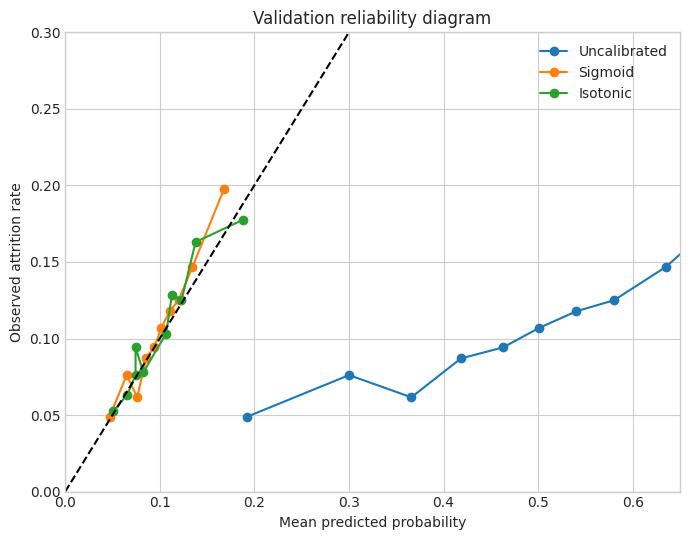

In [5]:
reliability = pd.read_csv(
    PROCESSED / "retention_reliability_bins.csv"
)

plt.figure(figsize=(7, 5.5))
for method, group in reliability.groupby("method", sort=False):
    plt.plot(
        group["mean_predicted_probability"],
        group["observed_attrition_rate"],
        marker="o",
        label=method,
    )

plt.plot([0, 0.65], [0, 0.65], color="black", linestyle="--")
plt.xlim(0, 0.65)
plt.ylim(0, 0.30)
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed attrition rate")
plt.title("Validation reliability diagram")
plt.legend()
plt.tight_layout()
plt.show()

Sigmoid calibration is selected because it sharply improves Brier score,
preserves the original ranking, and is statistically indistinguishable from
the more flexible isotonic mapping on validation Brier score.

## Ranking performance

Precision describes concentration within the reviewed group. Capture describes
the share of known attrition cases found. Lift compares the reviewed group with
random selection.

In [6]:
ranking = pd.read_csv(PROCESSED / "retention_ranking_metrics.csv")
reported_fractions = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00]
ranking_table = ranking.loc[
    ranking["requested_fraction"].isin(reported_fractions),
    [
        "requested_fraction",
        "selected_count",
        "precision_at_k",
        "capture_rate_at_k",
        "lift_at_k",
        "precision_at_k_lower_95",
        "precision_at_k_upper_95",
    ],
].copy()
display(ranking_table.round(3))

,requested_fraction,selected_count,precision_at_k,capture_rate_at_k,lift_at_k,precision_at_k_lower_95,precision_at_k_upper_95
0,0.01,56,0.250,0.024,2.355,0.143,0.393
2,0.05,277,0.209,0.099,1.973,0.168,0.262
3,0.10,553,0.197,0.186,1.857,0.167,0.230
5,0.20,1105,0.172,0.324,1.620,0.153,0.191
9,0.50,2761,0.139,0.654,1.307,0.130,0.147
11,1.00,5521,0.106,1.000,1.000,0.106,0.106


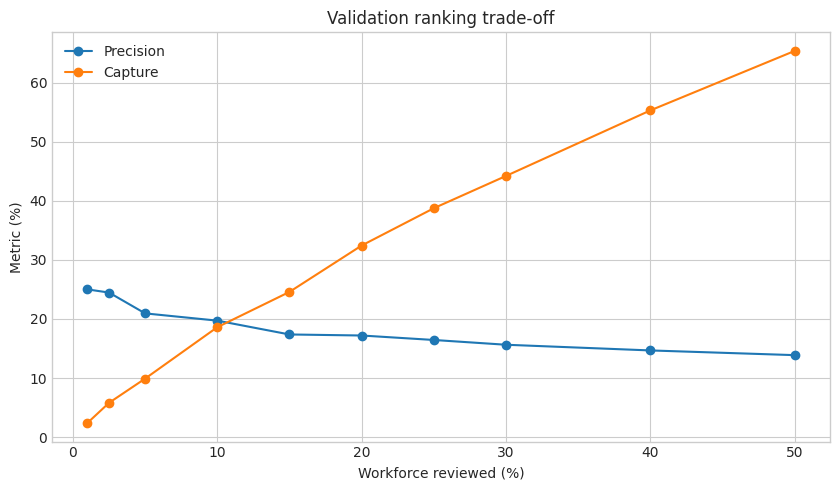

In [7]:
plot_ranking = ranking.loc[
    ranking["requested_fraction"] <= 0.50
].copy()

figure, axis = plt.subplots(figsize=(8.5, 5))
axis.plot(
    plot_ranking["requested_fraction"] * 100,
    plot_ranking["precision_at_k"] * 100,
    marker="o",
    label="Precision",
)
axis.plot(
    plot_ranking["requested_fraction"] * 100,
    plot_ranking["capture_rate_at_k"] * 100,
    marker="o",
    label="Capture",
)
axis.set(
    xlabel="Workforce reviewed (%)",
    ylabel="Metric (%)",
    title="Validation ranking trade-off",
)
axis.legend()
figure.tight_layout()
plt.show()

The highest-ranked 10% contains 18.6% of validation attrition cases and
achieves 1.86× lift. This is useful prioritization, not certainty about any
individual employee.

## Once-only final test

The policy and calibration choices are frozen before the 2025 target is
accessed. Test results are reported once and are not used for retuning.

In [8]:
final_test = pd.read_csv(
    PROCESSED / "retention_final_test_model_metrics.csv"
)
display(final_test.round(3))

,evaluation_period,rows,positive_cases,positive_rate,mean_predicted_probability,mean_calibration_gap,brier_score,pr_auc,roc_auc,top_decile_count,top_decile_precision,top_decile_capture,top_decile_lift
0,2025 final test,6641,803,0.121,0.11,-0.011,0.105,0.171,0.606,665,0.198,0.164,1.642


In [9]:
validation_row = models.loc[
    models["selected_model"].astype(bool)
].iloc[0]
test_row = final_test.iloc[0]

out_of_time_comparison = pd.DataFrame(
    {
        "period": ["2024 validation", "2025 final test"],
        "rows": [validation_row["rows"], test_row["rows"]],
        "positive_rate": [
            validation_row["positive_rate"],
            test_row["positive_rate"],
        ],
        "pr_auc": [validation_row["pr_auc"], test_row["pr_auc"]],
        "roc_auc": [validation_row["roc_auc"], test_row["roc_auc"]],
        "top_decile_lift": [
            validation_row["top_decile_lift"],
            test_row["top_decile_lift"],
        ],
    }
)
display(out_of_time_comparison.round(3))

,period,rows,positive_rate,pr_auc,roc_auc,top_decile_lift
0,2024 validation,5521,0.106,0.164,0.621,1.857
1,2025 final test,6641,0.121,0.171,0.606,1.642


The final test confirms moderate out-of-time ranking value, with 0.171 PR-AUC,
0.606 ROC-AUC, and 1.64× top-decile lift. The lower test ROC-AUC reinforces
the need for uncertainty, human review, and ongoing monitoring.

### Portfolio navigation

Previous: [Data Foundation and Temporal Design](01_data_foundation_and_temporal_design.ipynb)  
Next: [Fairness, Economics, and Retention Policy](03_fairness_economics_and_policy.ipynb)